<a href="https://colab.research.google.com/github/fadeeva/Risk_Alpha_Stable/blob/main/notebooks/Calibration_of_the_alpha-stable_dist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd

from scipy import stats
from scipy.stats import levy_stable
from scipy.optimize import minimize_scalar

import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Calibration of the alpha-stable distribution

## Data

In [3]:
url = 'https://github.com/fadeeva/Risk_Alpha_Stable/raw/refs/heads/main/data/'

data = {
    'btc-usd': pd.read_csv(f'{url}btc-usd.csv', parse_dates=True, index_col=0, header=[0, 1]),
    'gold': pd.read_csv(f'{url}gold.csv', parse_dates=True, index_col=0, header=[0, 1]),
    'spy' : pd.read_csv(f'{url}spy.csv', parse_dates=True, index_col=0, header=[0, 1]),
    'tlt': pd.read_csv(f'{url}tlt.csv', parse_dates=True, index_col=0, header=[0, 1]),
    'usdrub': pd.read_csv(f'{url}usdrub.csv', parse_dates=True, index_col=0, header=[0, 1]),
}

for ticker in data.keys():
    data[ticker]['log_return'] = np.log(data[ticker]['Close'].div(data[ticker]['Close'].shift(1)))
    data[ticker].dropna(axis=0, inplace=True)

# delete outlier
data['usdrub'].drop(['2023-03-16', '2023-03-17'], inplace=True)
data['usdrub'].drop(['log_return'], axis=1, inplace=True)
data['usdrub']['log_return'] = np.log(data['usdrub']['Close'].div(data['usdrub']['Close'].shift(1)))
data[ticker].dropna(axis=0, inplace=True)

In [17]:
N = 10_000
quantiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]

sample = levy_stable.rvs(.5, beta=0, size=N)
quantiles_model = np.percentile(sample, quantiles)

quantiles_data = {}
for ticker, asset in data.items():
    quantiles_data[ticker] = np.percentile(asset, quantiles)


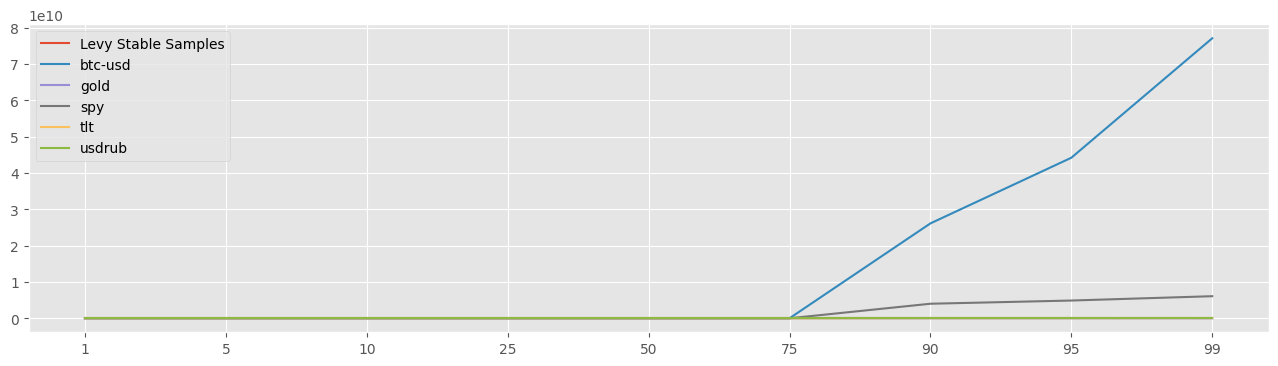

In [23]:
plt.figure(figsize=(16, 4))

plt.plot(np.arange(len(quantiles)), quantiles_model, label='Levy Stable Samples')
for ticker, q in quantiles_data.items():
    plt.plot(np.arange(len(quantiles)), q, label=f'{ticker}')

plt.xticks(np.arange(len(quantiles)), quantiles)
plt.legend();